In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
from sqlalchemy import create_engine
import ipywidgets as widgets
from IPython.display import display, clear_output

# Параметры подключения к базе данных
server = 'hq-srv-eis-new.irgups.ru'
database = 'eis_irgups'
username = 'eis_irgups'
password = 'eis_irgups'

# Строка подключения
connection_string = f"mysql+pymysql://{username}:{password}@{server}/{database}"
engine = create_engine(connection_string)

# SQL-запрос
query = """
SELECT DISTINCT
    sc.id AS stud_id,
    sg.name AS grp,
    CONCAT_WS(' ', pe.name1, pe.name2, pe.name3) AS stud_fio,
    k.name AS kafedra,
    f.short_name AS fac_short_name,
    e.exam AS exam_id,
    et.name AS predmet,
    CONCAT_WS(' ', emp.name1, emp.name2, emp.name3) AS prepodavatel,
    IF(p.semestr %% 2 = 0, p.semestr DIV 2, p.semestr DIV 2 + 1) AS course,
    p.semestr,
    sf.name AS form_obucheniya,
    con.name AS tip_dogovora,
    DATE_FORMAT(m.pass_date, '%%d.%%m.%%Y') AS pass_date,
    DATE_FORMAT(p.exdata, '%%d.%%m.%%Y') AS exdata
FROM courses c
JOIN contracts con ON con.id = c.contract_id
JOIN studyforms sf ON sf.id = c.studyform_id
JOIN stud_groups sg ON sg.id = c.group_id AND sg.fac_id IN (2, 11, 12, 13, 14)
JOIN stud_cards sc ON sc.id = c.stud_id
JOIN persons pe ON pe.id = sc.person_id
JOIN plans p ON p.group_id = c.group_id AND p.semestr < c.semestr
JOIN exams e ON e.id = p.exam_id
JOIN ex_type et ON et.id = p.examtype_id
LEFT JOIN marks m ON m.exam_id = p.exam_id 
    AND m.stud_id = c.stud_id 
    AND p.semestr = m.semestr 
    AND m.examtype_id = p.examtype_id
JOIN faculties f 
    ON f.id = sg.fac_id
    AND f.active = '1'
    AND f.filial_id = '1'
    AND f.diplom_name IS NOT NULL
JOIN employes emp ON emp.id = p.emp_id
LEFT JOIN kafedras k ON k.id = emp.kaf_id
WHERE c.active = 1 
    AND c.archived_id = 0
    AND (m.mark IN (0, 2, 1001, 1002, 1003, 1007) OR m.mark IS NULL)
ORDER BY sc.id;
"""

# Загрузка данных
df = pd.read_sql(query, engine)

# Переименование столбцов для удобства
df.rename(columns={
    'stud_id': 'ID студента',
    'grp': 'Группа',
    'stud_fio': 'ФИО студента',
    'kafedra': 'Кафедра',
    'fac_short_name': 'Сокращение факультета',
    'exam_id': 'ID экзамена',
    'predmet': 'Предмет',
    'prepodavatel': 'Преподаватель',
    'course': 'Курс',
    'semestr': 'Семестр',
    'form_obucheniya': 'Форма обучения',
    'tip_dogovora': 'Тип договора',
    'pass_date': 'Дата сдачи',
    'exdata': 'Дата экзамена'
}, inplace=True)

# Заполнение пропусков
df['Кафедра'] = df['Кафедра'].fillna('Кафедра не указана')
df['Преподаватель'] = df['Преподаватель'].fillna('Неизвестный')

# Глобальная переменная для хранения отфильтрованных данных
filtered_data = df.copy()

# Создание выпадающего списка для выбора факультета
faculty_options = ['Все'] + sorted(df['Сокращение факультета'].unique().tolist())
faculty_dropdown = widgets.Dropdown(
    options=faculty_options,
    description='Факультет:',
    value='Все'
)

# Функция для фильтрации данных по факультету
def filter_by_faculty(faculty):
    filtered_data = df.copy()
    
    # Фильтр по факультету
    if faculty != 'Все':
        filtered_data = filtered_data[filtered_data['Сокращение факультета'] == faculty]
    
    return filtered_data

# Функция для обновления данных при изменении фильтров
def update_data(change):
    global filtered_data  # Объявляем переменную как глобальную
    
    clear_output(wait=True)  # Очищаем предыдущий вывод
    print("Выбранный факультет:", faculty_dropdown.value)
    
    # Применяем фильтрацию
    filtered_data = filter_by_faculty(faculty_dropdown.value)
    
    # Выводим информацию о фильтрации
    print("Количество записей после фильтрации:", filtered_data.shape[0])
    print("Уникальные факультеты в данных:", filtered_data['Сокращение факультета'].unique())
    
    # Отображаем фильтр снова
    display(faculty_dropdown)

# Привязываем обработчик событий к изменениям в виджете
faculty_dropdown.observe(update_data, names='value')

# Отображение фильтра
display(faculty_dropdown)

# Первичная фильтрация данных
update_data(None)

Выбранный факультет: Все
Количество записей после фильтрации: 18735
Уникальные факультеты в данных: ['ФТС' 'ФУТиИТ' 'ФСОТ' 'ФЭиУ' 'ФСЖД']


Dropdown(description='Факультет:', options=('Все', 'ФСЖД', 'ФСОТ', 'ФТС', 'ФУТиИТ', 'ФЭиУ'), value='Все')

In [3]:
# Группировка данных по уровням обучения
levels = [
    'Бакалавриат (очное)',
    'Бакалавриат (заочное)',
    'Специалитет (очное)',
    'Специалитет (заочное)',
    'Специалитет (заочное ускоренное)',
    'Магистратура (очное)',
    'Магистратура (очно-заочное)',
    'Магистратура (заочное)'
]

for level in levels:
    level_data = filtered_data[
        (filtered_data['Форма обучения'].str.lower().str.contains(level.split(' ')[0].lower(), na=False)) &
        (filtered_data['Группа'].str.strip().str.endswith('(' + level.split(' ')[1][0] + ',' + level.split(' ')[2][0] + ')', na=False))
    ]
    print(f"\nУровень обучения: {level}")
    print("Количество записей:", level_data.shape[0])
    print("Уникальные группы:", level_data['Группа'].unique())

IndexError: list index out of range

In [4]:
print("Уникальные значения в столбце 'Форма обучения':")
print(df['Форма обучения'].unique())

print("\nУникальные значения в столбце 'Группа':")
print(df['Группа'].unique())

Уникальные значения в столбце 'Форма обучения':
['специалитет (заочное)' 'бакалавриат (очное)' 'бакалавриат (заочное)'
 'специалитет (очное)' 'магистратура (очно-заочное)'
 'магистратура (заочное)' 'магистратура (очное)'
 'специалитет (заочное ускоренное)']

Уникальные значения в столбце 'Группа':
['ПСЖ.3-22-1(И,З)' 'ПИ.1-12-1(И,О)' 'СОД.2-19-1(И,З)' 'ПСЖ.3-20-1(И,З)'
 'Э.9-20-1(И,З)' 'ЭЖД.1-21-2(И,З)' 'ЭЖД.1-20-3(И,З)' 'СЖД.1-20-1(И,З)'
 'СЖД.2-20-1(И,З)' 'ЭЖД.1-21-1(И,З)' 'ИС.1-21-1(И,З)' 'ЭБ.1-23-1(И,З)'
 'ПСЖ.3-21-1(И,З)' 'ЭЖД.1-20-1(И,З)' 'ПСЖ.6-22-1(И,З)' 'ПСЖ.6-21-1(И,З)'
 'СОД.1-21-2(И,О)' 'УК.1-22-1(И,О)' 'ЭБ.1-22-1(И,З)' 'СЖД.2-21-1(И,З)'
 'ЭЖД.1-21-1(И,О)' 'Т-20-1(И,З)' 'Т-19-1(И,З)' 'УПп.1-20-1(И,З)'
 'ЭЖД.3-21-1(И,З)' 'ЭЖД.1-19-2(И,З)' 'СЖД.1-21-1(И,З)' 'СЖД.3-21-1(И,О)'
 'СОД.2-21-1(И,З)' 'СОД.3-21-1(И,З)' 'ТТП.1-23-1(И,О)' 'ТТП.1-21-1(И,О)'
 'ТТП.1-22-1(И,О)' 'ЭЖД.1-22-1(И,З)' 'ПСЖ.3-19-1(И,З)' 'ЭБ.1-21-1(И,З)'
 'Э.5-21-1(И,О)' 'СОД.1-22-1(И,О)' 'СОД.1-22-1(И,З)' 'СОД.1-

In [5]:
# Проверка записей для "Специалитет (очное)"
test_data = filter_data("ФСОТ", "Специалитет (очное)")
print("Количество записей для Специалитет (очное):", test_data.shape[0])
print(test_data)

NameError: name 'filter_data' is not defined

In [23]:
import plotly.express as px

# Функция для создания древовидной карты
def create_treemap(filtered_data, level_name):
    # Подсчет количества долгов по группам
    group_debt_summary = filtered_data.groupby('Группа').agg({
        'ФИО студента': 'nunique',  # Количество студентов с долгами
        'Предмет': 'count'          # Общее количество долгов
    }).reset_index().rename(columns={'ФИО студента': 'Количество_студентов', 'Предмет': 'Количество_долгов'})

    # Создание древовидной карты
    fig = px.treemap(
        group_debt_summary,
        path=['Группа'],  # Иерархия данных
        values='Количество_долгов',  # Размер прямоугольников
        color='Количество_долгов',  # Цветовая шкала
        color_continuous_scale='reds',  # Цветовая палитра
        title=f'Распределение долгов по группам ({level_name})'
    )

    # Настройка внешнего вида
    fig.update_layout(
        margin=dict(t=50, l=25, r=25, b=25),
        font=dict(size=12)
    )

    # Отображение графика
    fig.show()

# Проверка, что данные отфильтрованы по факультету
if filtered_data.empty:
    print("Нет данных для выбранного факультета.")
else:
    # Разделение данных по уровням обучения
    levels = [
        ('Бакалавриат (очное)', '(И,О)'),
        ('Бакалавриат (заочное)', '(И,З)'),
        ('Специалитет (очное)', '(И,О)'),
        ('Специалитет (заочное)', '(И,З)'),
        ('Специалитет (заочное ускоренное)', '(И,ЗУ)'),
        ('Магистратура (очное)', '(И,О)'),
        ('Магистратура (очно-заочное)', '(И,ОЗ)'),
        ('Магистратура (заочное)', '(И,З)')
    ]

    for level_name, group_suffix in levels:
        # Фильтрация данных по уровню обучения
        level_data = filtered_data[
            (filtered_data['Форма обучения'].str.contains(level_name.split(' ')[0])) & 
            (filtered_data['Группа'].str.endswith(group_suffix))
        ]

        if not level_data.empty:
            # Создание древовидной карты для текущего уровня
            create_treemap(level_data, level_name)
        else:
            print(f"Нет данных для уровня: {level_name}")

Нет данных для уровня: Бакалавриат (очное)
Нет данных для уровня: Бакалавриат (заочное)
Нет данных для уровня: Специалитет (очное)
Нет данных для уровня: Специалитет (заочное)
Нет данных для уровня: Специалитет (заочное ускоренное)
Нет данных для уровня: Магистратура (очное)
Нет данных для уровня: Магистратура (очно-заочное)
Нет данных для уровня: Магистратура (заочное)


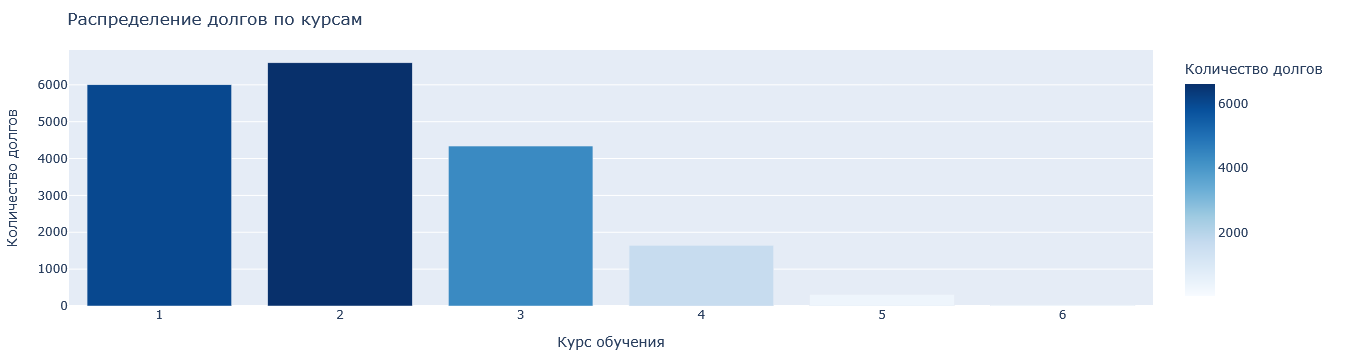

In [6]:
import plotly.express as px

# Подсчет количества долгов по курсам
course_debt_summary = df.groupby('Курс').agg({
    'ФИО студента': 'nunique',  # Количество студентов с долгами
    'Предмет': 'count'          # Общее количество долгов
}).reset_index().rename(columns={'ФИО студента': 'Количество_студентов', 'Предмет': 'Количество_долгов'})

# Создание столбчатой диаграммы
fig = px.bar(
    course_debt_summary,
    x='Курс',
    y='Количество_долгов',
    title='Распределение долгов по курсам',
    labels={'Курс': 'Курс обучения', 'Количество_долгов': 'Количество долгов'},
    color='Количество_долгов',
    color_continuous_scale='blues'
)

# Настройка внешнего вида
fig.update_layout(
    xaxis_title='Курс обучения',
    yaxis_title='Количество долгов',
    margin=dict(t=50, l=25, r=25, b=25),
    font=dict(size=12)
)

# Отображение графика
fig.show()

In [3]:
import ipywidgets as widgets
from IPython.display import display

faculty_dropdown = widgets.Dropdown(
    options=['Все'] + list(df['Факультет'].unique()),
    value='Все',
    description='Факультет:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

max_old_debt = widgets.IntSlider(
    value=2,
    min=0,
    max=10,
    description='Макс. долгов старше года:',
    layout=widgets.Layout(width='400px')
)

show_budget_only = widgets.Checkbox(
    value=True,
    description='Только бюджетники',
    indent=False
)

def show_promising_students(faculty, max_old, budget_only):
    filtered = grouped_df[grouped_df['Долгов старше года'] <= max_old]
    
    if faculty != 'Все':
        filtered = filtered[filtered['Факультет'] == faculty]
        
    if budget_only:
        filtered = filtered[filtered['Тип договора'] == 'бюджет']
    
    styled = filtered[['ФИО студента', 'Факультет', 'Группа', 'Тип договора',
                       'Долгов за текущий семестр', 'Долгов старше года', 'Общее количество долгов']] \
        .style.background_gradient(subset=['Долгов за текущий семестр'], cmap='Greens') \
        .background_gradient(subset=['Долгов старше года'], cmap='YlGnBu') \
        .format({
            'Долгов за текущий семестр': '{:.0f}',
            'Долгов старше года': '{:.0f}',
            'Общее количество долгов': '{:.0f}'
        }) \
        .set_properties(**{
            'text-align': 'center',
            'font-family': 'Arial',
            'border': '1px solid lightgray'
        }) \
        .set_caption("Студенты с минимальным риском академической задолженности")

    display(styled)
    print(f"\nНайдено студентов: {len(filtered)}")

# Отображение виджетов
widgets.interact(
    show_promising_students,
    faculty=faculty_dropdown,
    max_old=max_old_debt,
    budget_only=show_budget_only
);

NameError: name 'df' is not defined

In [5]:
# Просмотр первых строк DataFrame
print("Первые строки данных:")
display(df.head())

# Информация о типах данных и пропусках
print("\nИнформация о данных:")
df.info()

# Проверка наличия пропусков
print("\nКоличество пропущенных значений в каждом столбце:")
display(df.isnull().sum())

# Если сравниваем с предыдущим периодом — можно добавить аналогично df_old

Первые строки данных:


,ID студента,Группа,ФИО студента,Кафедра,exam_id,Предмет,Преподаватель,Семестр,Курс,Форма обучения,Тип договора,Факультет,Сокращение факультета,Текущий_семестр_группы,Возраст_долга,Долгов за текущий семестр,Долгов за прошлый семестр,Долгов старше года,Общее количество долгов
0,89646,"Т-19-1(И,З)",Громова Екатерина Юрьевна,Математика,Математика,зачет,Черняева Татьяна Николаевна,1,1,специалитет (заочное),внебюджет,Факультет «Экономика и управление»,ФЭиУ,12,11,0,0,1,1
1,89646,"Т-19-1(И,З)",Громова Екатерина Юрьевна,Философия и социально-гуманитарные науки,История,экзамен,Афанасова Елена Николаевна,1,1,специалитет (заочное),внебюджет,Факультет «Экономика и управление»,ФЭиУ,12,11,0,0,1,1
2,89646,"Т-19-1(И,З)",Громова Екатерина Юрьевна,Информационные системы и защита информации,Информатика,зачет,Деканова Нина Петровна,1,1,специалитет (заочное),внебюджет,Факультет «Экономика и управление»,ФЭиУ,12,11,0,0,1,1
3,89646,"Т-19-1(И,З)",Громова Екатерина Юрьевна,"Кафедра ""Физическая культура""",Физическая культура и спорт,зачет,Власов Е.А.,1,1,специалитет (заочное),внебюджет,Факультет «Экономика и управление»,ФЭиУ,12,11,0,0,1,1
4,89646,"Т-19-1(И,З)",Громова Екатерина Юрьевна,Иностранные языки,Иностранный язык,зачет,Юрковская Елена Александровна,1,1,специалитет (заочное),внебюджет,Факультет «Экономика и управление»,ФЭиУ,12,11,0,0,1,1



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181103 entries, 0 to 181102
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   ID студента                181103 non-null  int64 
 1   Группа                     181103 non-null  object
 2   ФИО студента               181103 non-null  object
 3   Кафедра                    181103 non-null  object
 4   exam_id                    181103 non-null  object
 5   Предмет                    181103 non-null  object
 6   Преподаватель              181103 non-null  object
 7   Семестр                    181103 non-null  int64 
 8   Курс                       181103 non-null  int64 
 9   Форма обучения             181103 non-null  object
 10  Тип договора               181103 non-null  object
 11  Факультет                  181103 non-null  object
 12  Сокращение факультета      181103 non-null  object
 13  Текущий_семестр_группы

ID студента                  0
Группа                       0
ФИО студента                 0
Кафедра                      0
exam_id                      0
Предмет                      0
Преподаватель                0
Семестр                      0
Курс                         0
Форма обучения               0
Тип договора                 0
Факультет                    0
Сокращение факультета        0
Текущий_семестр_группы       0
Возраст_долга                0
Долгов за текущий семестр    0
Долгов за прошлый семестр    0
Долгов старше года           0
Общее количество долгов      0
dtype: int64

In [4]:
# Виджет для выбора формы обучения
forma_widget = widgets.Dropdown(
    options=['Все', 'Очная', 'Заочная'],
    value='Все',
    description='Форма обучения:'
)

def filter_by_form(forma):
    if forma == 'Очная':
        return df[df['Группа'].str.endswith('(И,О)')]
    elif forma == 'Заочная':
        return df[df['Группа'].str.endswith('(И,З)')]
    else:
        return df

def show_group_stats(forma):
    filtered = filter_by_form(forma)
    total_students = filtered.shape[0]
    total_debts = filtered['Общее количество долгов'].sum()
    print(f"\nФорма обучения: {forma}")
    print(f"Количество студентов с долгами: {total_students}")
    print(f"Общее количество долгов: {total_debts}")

# Отображение виджета и результатов
output = widgets.interactive_output(show_group_stats, {'forma': forma_widget})
display(forma_widget, output)

Dropdown(description='Форма обучения:', options=('Все', 'Очная', 'Заочная'), value='Все')

Output()

In [5]:
# Виджет для включения/исключения практик
include_praktika = widgets.Checkbox(
    value=False,
    description='Учитывать практики',
    indent=False
)

def toggle_praktika(include):
    if include:
        return df  # Возвращаем все данные
    else:
        # Исключаем строки, где предмет начинается с "Учебная" или "Производственная"
        return df[~df['Предмет'].str.startswith(('Учебная', 'Производственная'), na=True)]

def update_stats(include):
    filtered = toggle_praktika(include)
    print(f"\n{'С учетом' if include else 'Без учета'} практик")
    print(f"Число студентов: {filtered.shape[0]}")
    print(f"Общее число долгов: {filtered['Общее количество долгов'].sum()}")

# Отображение
output_praktika = widgets.interactive_output(update_stats, {'include': include_praktika})
display(include_praktika, output_praktika)

Checkbox(value=False, description='Учитывать практики', indent=False)

Output()